In [13]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
from tqdm import tqdm
import importlib
import open3d as o3d

# ==========================================
# 1. PATH & DEVICE CONFIGURATION
# ==========================================
BASE_DIR = os.getcwd()
sys.path.append(os.path.join(BASE_DIR, 'models'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Project Root: {BASE_DIR}")
print(f"Using Device: {device}")

# ==========================================
# 2. REGRESSION DATASET CLASS
# ==========================================
class ChamferRegressionDataset(Dataset):
    def __init__(self, csv_file, pcd_dir, num_points=1024):
        self.metadata = pd.read_csv(csv_file)
        self.pcd_dir = pcd_dir
        self.num_points = num_points

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        filename = self.metadata.iloc[idx, 0]
        chamfer = self.metadata.iloc[idx, 3] 
        asymmetry = self.metadata.iloc[idx, 4]

        file_path = os.path.normpath(os.path.join(self.pcd_dir, filename))
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Missing file: {file_path}")
            
        pcd = o3d.io.read_point_cloud(file_path)
        
        # A. Furthest Point Sampling (FPS)
        if len(pcd.points) > self.num_points:
            pcd = pcd.farthest_point_down_sample(self.num_points)
        
        # B. Re-estimate Normals (Crucial: FPS creates a new object without normals)
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
        pcd.orient_normals_towards_camera_location([0, 0, 0])
        
        xyz = np.asarray(pcd.points)
        normals = np.asarray(pcd.normals)
        
        if xyz.shape[0] == 0:
            raise ValueError(f"File {filename} is empty.")

        # Combine into [N, 6]
        points = np.hstack((xyz, normals))
        
        # C. Centering
        points[:, 0:3] -= np.mean(points[:, 0:3], axis=0)
        
        # D. Padding Fallback (if original points < 1024)
        if len(points) < self.num_points:
            idx_sample = np.random.choice(len(points), self.num_points, replace=True)
            points = points[idx_sample]
        
        # E. Transpose to [Channels, Points] for PointNet++
        points_tensor = torch.tensor(points, dtype=torch.float32).transpose(1, 0)
        target_tensor = torch.tensor([chamfer, asymmetry], dtype=torch.float32)
        
        return points_tensor, target_tensor

# ==========================================
# 3. TRAINING & VALIDATION ENGINE
# ==========================================
def run_training(model, train_loader, val_loader, optimizer, criterion, epochs):
    best_val_loss = float('inf')
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_asym_mse': [],
        'val_chamfer_mse': []
    }
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        train_loss = 0
        
        for points, target in train_loader:
            points, target = points.to(device), target.to(device)
            optimizer.zero_grad()
            
            # pred, _ = model(points)
            # loss = criterion(pred, target)

            pred, trans_feat = model(points)
            loss = criterion(pred, target, trans_feat)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION ---
        model.eval()
        val_loss = 0
        val_asym_mse = 0
        val_chamfer_mse = 0
        
        with torch.no_grad():
            for points, target in val_loader:
                points, target = points.to(device), target.to(device)

                # pred, _ = model(points)
                # v_loss = criterion(pred, target)

                pred, trans_feat = model(points)
                v_loss = criterion(pred, target, trans_feat)

                val_loss += v_loss.item()
                
                # Split metrics (Index 0: Asymmetry, Index 1: Chamfer)
                asym_mse = F.mse_loss(pred[:, 0], target[:, 0])
                chamfer_mse = F.mse_loss(pred[:, 1], target[:, 1])
                
                val_asym_mse += asym_mse.item()
                val_chamfer_mse += chamfer_mse.item()
        
        avg_val_loss = val_loss / len(val_loader)
        avg_asym_mse = val_asym_mse / len(val_loader)
        avg_chamfer_mse = val_chamfer_mse / len(val_loader)
        
        # Save to history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_asym_mse'].append(avg_asym_mse)
        history['val_chamfer_mse'].append(avg_chamfer_mse)
        
        # Clean printed summary
        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | Asym: {avg_asym_mse:.4f} | Chamfer: {avg_chamfer_mse:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_regression_model.pth')
            print(f">>> New Best Model Saved (Val Loss: {avg_val_loss:.4f})")

    return history

# ==========================================
# 4. EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # --- Config ---
    BATCH_SIZE = 16
    LR = 5e-4
    EPOCHS = 250
    METADATA_PATH = '../anr_pkg/src/processed_data/training_first/metadata.csv'
    PCD_DATA_DIR = '../anr_pkg/src/viewpoints_candidate/testing_data/training_first/'

    # --- Data Setup ---
    full_dataset = ChamferRegressionDataset(METADATA_PATH, PCD_DATA_DIR)
    
    # 80/20 Split
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Total Samples: {len(full_dataset)} | Training: {len(train_ds)} | Validation: {len(val_ds)}")

    # --- Model Setup ---
    reg_module = importlib.import_module('pointnet_regression')
    model = reg_module.get_model(normal_channel=True).to(device)
    criterion = reg_module.get_loss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

    # --- Run ---
    train_history = run_training(model, train_loader, val_loader, optimizer, criterion, EPOCHS)

Project Root: c:\Users\Alvan\Documents\Alvan\Data\Code\Python\Main\pointnet_pytorch_reflective
Using Device: cuda
Total Samples: 252 | Training: 201 | Validation: 51
Epoch 1/250 | Train: 53.1655 | Val: 50.9308 | Asym: 94.0380 | Chamfer: 7.6922
>>> New Best Model Saved (Val Loss: 50.9308)
Epoch 2/250 | Train: 45.1327 | Val: 33.4775 | Asym: 59.1624 | Chamfer: 7.1477
>>> New Best Model Saved (Val Loss: 33.4775)
Epoch 3/250 | Train: 36.8174 | Val: 36.9585 | Asym: 57.6594 | Chamfer: 15.3799
Epoch 4/250 | Train: 31.0192 | Val: 37.7835 | Asym: 69.4871 | Chamfer: 5.6202
Epoch 5/250 | Train: 27.1750 | Val: 37.1470 | Asym: 69.8547 | Chamfer: 4.2062
Epoch 6/250 | Train: 22.2085 | Val: 33.4575 | Asym: 62.4667 | Chamfer: 3.8364
>>> New Best Model Saved (Val Loss: 33.4575)
Epoch 7/250 | Train: 19.3608 | Val: 22.3650 | Asym: 38.2148 | Chamfer: 5.3326
>>> New Best Model Saved (Val Loss: 22.3650)
Epoch 8/250 | Train: 16.6855 | Val: 33.2737 | Asym: 60.8115 | Chamfer: 5.5146
Epoch 9/250 | Train: 14.9417 

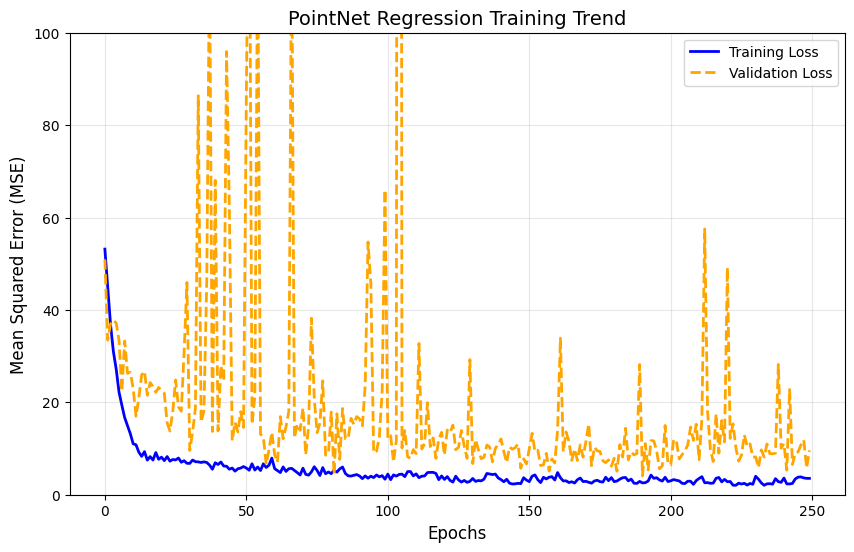

In [15]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    plt.figure(figsize=(10, 6))
    
    # Plot Training Loss
    plt.plot(history['train_loss'], label='Training Loss', color='blue', linewidth=2)
    
    # Plot Validation Loss
    plt.plot(history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
    
    plt.title('PointNet Regression Training Trend', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.ylim(0, 100)
    
    # Save the plot as an image for your thesis report
    plt.savefig('training_trend.png')
    plt.show()

# Generate the plot
plot_learning_curves(train_history)

In [35]:
# Inference

import torch
import importlib

INDEX = 86  # Change this index to test different samples from the dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

reg_module = importlib.import_module('pointnet_regression')
model = reg_module.get_model(normal_channel=True).to(device)

model.load_state_dict(torch.load('data/training_first_pointnet/best_regression_model.pth'))
model.eval()

points, target = full_dataset[INDEX]   # reuse dataset pipeline

points = points.unsqueeze(0).to(device)   # [1, 6, 1024]

with torch.no_grad():
    pred, _ = model(points)


pred = pred.squeeze(0).cpu().numpy()
print("Predicted (CD, Asymmetry): ", pred)
print("Ground Truth (CD, Asymmetry): ", target.numpy())

Predicted (CD, Asymmetry):  [26.305334 20.300346]
Ground Truth (CD, Asymmetry):  [28.543037 19.63048 ]


In [36]:
# Check Processed PCD

import open3d as o3d
import numpy as np

# 1. Get the sample from your dataset
# sample_pts is [6, 1024]
sample_pts, sample_targ = train_ds[INDEX]

# 2. Convert to NumPy and Transpose back to [1024, 6]
points_np = sample_pts.numpy().T 

# 3. Separate XYZ and Normals
xyz = points_np[:, :3]
normals = points_np[:, 3:]

# 4. Create Open3D object
pcd_to_vis = o3d.geometry.PointCloud()
pcd_to_vis.points = o3d.utility.Vector3dVector(xyz)
pcd_to_vis.normals = o3d.utility.Vector3dVector(normals)

print(f"Visualizing Sample with Targets: {sample_targ.tolist()}")
print("Close the Open3D window to continue...")

# 5. Draw
o3d.visualization.draw_geometries([pcd_to_vis], 
                                  window_name="Fixed Sampled PCD (1024 points)",
                                  width=800, height=600)

Visualizing Sample with Targets: [10.735368728637695, 2.671574354171753]
Close the Open3D window to continue...


In [ ]:
# Analyze the Model

model.eval()

points, _ = train_ds[INDEX]
points = points.unsqueeze(0).to(device)

pred, (l1_xyz, l1_points, _, _) = model(points)

# l1_points shape: [1, C, N]
features = l1_points.squeeze(0).detach().cpu().numpy()  # [C, N]
xyz = l1_xyz.squeeze(0).detach().cpu().numpy()         # [3, N]

# Pick a neuron channel
channel_id = 55  # arbitrary neuron
activation = features[channel_id]  # [N]

# Select top-k activating point
k = 100
top_idx = activation.argsort()[-k:]
selected_points = xyz[:, top_idx].T

# Visualize
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(selected_points)


colors = np.zeros((xyz.shape[1], 3))
colors[top_idx] = [1, 0, 0]  # highlight in red

pcd.points = o3d.utility.Vector3dVector(xyz.T)
pcd.colors = o3d.utility.Vector3dVector(colors)


o3d.visualization.draw_geometries([pcd])

ValueError: not enough values to unpack (expected 4, got 1)